# Compare Output Segmentations

Let's compare U-Net outputs with NVAE-Corrector outputs.

In [1]:
import os

# Change this variable if the root folder name has been changed
root_dir = "nvae-shape-encoding"
current_dir = os.getcwd()

if not current_dir.endswith(root_dir):
    %cd ..

assert os.getcwd().endswith(root_dir)

/Users/freddy/Unshared/nvae-shape-encoding


/Users/freddy/Unshared/nvae-shape-encoding/venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


We don't have to perform inference for U-Net, since the predictions are already
saved for the Mask-to-Mask pipeline.

Update `model_path` to choose the model.

In [2]:
from arch.nvae_corrector.nvae_corrector import NVAECorrector
from arch.vae_corrector.vae_corrector import VAECorrector
from arch.cnvae.cnvae import CNVAE
from arch.unet.acunet import ACUNet
from arch.unet.acunet_vae import ACVAEUNet

nvae_m2m_extended = "logs/nvae_corrector_acdc/default-extended/checkpoints/epoch=20-step=17976.ckpt"
# vae_m2m = "logs/vae_corrector_acdc/best/checkpoints/epoch=40-step=4387.ckpt"
vae_m2m = "logs/vae_corrector_acdc/extended/b-2-latent-32/checkpoints/epoch=11-step=5136.ckpt"
nvae_acunet = "logs/unet_acdc/default-shape-prior/checkpoints/epoch=67-step=3672.ckpt"
vae_acunet = "logs/unet_acdc/shape-prior-vae-baselines/shape-prior-vae-seed-1974/checkpoints/epoch=64-step=3510.ckpt"
cnvae_i2m = "logs/cnvae_acdc/best/checkpoints/epoch=83-step=17976.ckpt"


/Users/freddy/Unshared/nvae-shape-encoding/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import lightning as L
import torch

from utils.const import SEED
from data_modules.acdc import ACDC3DWithPredictedMaskDataModule
from utils.utils import setup_device

# Setup device
device = setup_device()
print(f"Device: {device}")

# Seed
L.seed_everything(SEED)

# Load data
data_module = ACDC3DWithPredictedMaskDataModule()

# Load models
models_nvae_m2m_extended = NVAECorrector.load_from_checkpoint(nvae_m2m_extended)
models_vae_m2m = VAECorrector.load_from_checkpoint(vae_m2m)
models_nvae_acunet = ACUNet.load_from_checkpoint(nvae_acunet)
models_vae_acunet = ACVAEUNet.load_from_checkpoint(vae_acunet)
models_cnvae_i2m = CNVAE.load_from_checkpoint(cnvae_i2m)

# Reseed after preprocessing data
L.seed_everything(SEED)

/Users/freddy/Unshared/nvae-shape-encoding/venv/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Seed set to 1969


Device: mps
Scans has size 100 with shape of 1st element torch.Size([10, 1, 128, 128])
Masks has size 100 with shape of 1st element torch.Size([10, 4, 128, 128])
Masks_pred has size 100 with shape of 1st element torch.Size([10, 4, 128, 128])
Conditions has size 100
eds has size 100


/Users/freddy/Unshared/nvae-shape-encoding/venv/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Seed set to 1969


1969

In [4]:
loader_test = data_module.test_dataloader()
y, y_pred, _, _ = next(iter(loader_test))
print(y.shape, y_pred.shape)

torch.Size([1, 10, 4, 128, 128]) torch.Size([1, 10, 4, 128, 128])


## View Segmentations

Let's seek the worst U-Net predictions in terms of anatomical validity, and see
how NVAE-Corrector improves them.

In [ ]:
# Do not use a data loader, since scans are encapsulated. Furthermore, not
# further preprocessing is done in Dataset.__getitem__.

data = data_module.data_test

print(data.scans[0].shape)
print(data.masks[0].shape)
print(data.masks_pred[0].shape)

print(len(data))

torch.Size([10, 1, 128, 128])
torch.Size([10, 4, 128, 128])
torch.Size([10, 4, 128, 128])
100


In [6]:
from utils.anatomical_validity_checker import AnatomicalValidityChecker
from utils.eval import compute_dice_score
from utils.utils import discretise

loader_test = data_module.test_dataloader()

worst_x = []
worst_y = []
worst_y_pred = []
worst_y_hat_nvae_m2m_extended = []
worst_y_hat_vae_m2m = []
worst_y_hat_nvae_acunet = []
worst_y_hat_vae_acunet = []
worst_y_hat_cnvae_i2m = []

with torch.no_grad():
    # models_nvae_acunet = ACUNet.load_from_checkpoint(nvae_acunet)
    # models_vae_acunet = ACVAEUNet.load_from_checkpoint(vae_acunet)
    # models_cnvae_i2m = CNVAE.load_from_checkpoint(cnvae_i2m)
    
    models = [models_nvae_m2m_extended, models_vae_m2m, models_nvae_acunet, models_vae_acunet, models_cnvae_i2m]
    
    for model in models:
        model.eval()
        model.to(device)
    
    for i in range(len(data)):
    # for i in range(10):
        # 3D data
        xs = data.scans[i]
        ys = data.masks[i]
        y_preds = data.masks_pred[i]
        
        for x, y, y_pred in zip(xs, ys, y_preds):
            # Individual 2D slice
            x = x.unsqueeze(0)
            y = y.unsqueeze(0)
            y_pred = y_pred.unsqueeze(0)

            x = x.to(device)
            y = y.to(device)
            y_pred = y_pred.to(device)

            y_hat_logits_nvae_m2m_extended, _, _, _, _ = models_nvae_m2m_extended(y_pred, test=True)
            y_hat_onehot_nvae_m2m_extended = discretise(y_hat_logits_nvae_m2m_extended)
            
            _, _, _, y_hat_logits_vae_m2m = models_vae_m2m(y_pred, test=True)
            y_hat_onehot_vae_m2m = discretise(y_hat_logits_vae_m2m)
            
            y_hat_logits_nvae_acunet = models_nvae_acunet(x)
            y_hat_onehot_nvae_acunet = discretise(y_hat_logits_nvae_acunet)
            
            y_hat_logits_vae_acunet = models_vae_acunet(x)
            y_hat_onehot_vae_acunet = discretise(y_hat_logits_vae_acunet)
            
            y_hat_logits_cnvae_i2m = models_cnvae_i2m.inference(x)
            y_hat_onehot_cnvae_i2m = discretise(y_hat_logits_cnvae_i2m)
            
            # Condition: Anatomically invalid U-Net prediction
            
            for discretised_y_hat in y_pred:
                AV = AnatomicalValidityChecker(discretised_y_hat)

                if AV.count_violations() > 1:
                    worst_x.append(x)
                    worst_y.append(y)
                    worst_y_pred.append(y_pred)
                    worst_y_hat_nvae_m2m_extended.append(y_hat_onehot_nvae_m2m_extended)
                    worst_y_hat_vae_m2m.append(y_hat_onehot_vae_m2m)
                    worst_y_hat_nvae_acunet.append(y_hat_onehot_nvae_acunet)
                    worst_y_hat_vae_acunet.append(y_hat_onehot_vae_acunet)
                    worst_y_hat_cnvae_i2m.append(y_hat_onehot_cnvae_i2m)

print(len(worst_x))

75


In [7]:
# Choose the samples to view

# samples_idx = torch.arange(0, len(worst_x))

# Figure 1
#                             0  1  2   3   4   5   6   7   8   9       11      13      15      17
# samples_idx = torch.Tensor([2, 9, 10, 11, 18, 19, 21, 33, 34, 35, 39, 48, 49, 50, 63, 66, 71, 74]).int()
samples_idx = torch.Tensor([11, 66, 21, 71]).int()

# Figure 2
# samples_idx = torch.Tensor([7, 51, 55, 68, 69, 73]).int()


worst_x_subset = torch.stack([worst_x[i] for i in samples_idx]).squeeze(1)
worst_y_subset = torch.stack([worst_y[i] for i in samples_idx]).squeeze(1)
worst_y_pred_subset = torch.stack([worst_y_pred[i] for i in samples_idx]).squeeze(1)
worst_y_hat_subset_nvae_m2m_extended = torch.stack([worst_y_hat_nvae_m2m_extended[i] for i in samples_idx]).squeeze(1)
worst_y_hat_subset_vae_m2m = torch.stack([worst_y_hat_vae_m2m[i] for i in samples_idx]).squeeze(1)
worst_y_hat_subset_nvae_acunet = torch.stack([worst_y_hat_nvae_acunet[i] for i in samples_idx]).squeeze(1)
worst_y_hat_subset_vae_acunet = torch.stack([worst_y_hat_vae_acunet[i] for i in samples_idx]).squeeze(1)
worst_y_hat_subset_cnvae_i2m = torch.stack([worst_y_hat_cnvae_i2m[i] for i in samples_idx]).squeeze(1)

(
    worst_x_subset.shape,
    worst_y_subset.shape,
    worst_y_pred_subset.shape,
    worst_y_hat_subset_nvae_m2m_extended.shape,
    worst_y_hat_subset_vae_m2m.shape,
    worst_y_hat_subset_nvae_acunet.shape,
    worst_y_hat_subset_vae_acunet.shape,
    worst_y_hat_subset_cnvae_i2m.shape,
)

(torch.Size([4, 1, 128, 128]),
 torch.Size([4, 4, 128, 128]),
 torch.Size([4, 4, 128, 128]),
 torch.Size([4, 4, 128, 128]),
 torch.Size([4, 4, 128, 128]),
 torch.Size([4, 4, 128, 128]),
 torch.Size([4, 4, 128, 128]),
 torch.Size([4, 4, 128, 128]))

In [8]:
corrector_ids = [
    r"$\text{U-Net}$",
    r"$\text{AC-UNet}$",
    r"$\text{AC-UNet}_{\text{NVAE}}$",
    r"$\text{CNVAE}_{\text{Seg}}$",
    r"$\text{CVAE}_{\text{Edit}}$",
    r"$\text{CNVAE}_{\text{Edit}}$",
]

worst_y_hat_subsets = [
    worst_y_pred_subset,
    worst_y_hat_subset_vae_acunet,
    worst_y_hat_subset_nvae_acunet,
    worst_y_hat_subset_cnvae_i2m,
    worst_y_hat_subset_vae_m2m,
    worst_y_hat_subset_nvae_m2m_extended,
]

In [9]:
# Compute Dice score and AV

corrector_dscs = []
corrector_violations = []

for i, y_hat_onehot in enumerate(worst_y_hat_subsets):
    dscs_arr = []
    violations_arr = []
    
    # Go through each slice
    for j, y_hat_onehot_slice in enumerate(y_hat_onehot):
        y_hat_onehot_slice = y_hat_onehot_slice.unsqueeze(0)
        y = worst_y_subset[j].unsqueeze(0)
        
        dice_score, dice_score_per_class = compute_dice_score(
            y,
            y_hat_onehot_slice,
            device,
            is_3d=True,
            dice_per_class=True,
        )
        
        # Compute anatomical violations
        
        AV = AnatomicalValidityChecker(y_hat_onehot_slice.squeeze(0))
        violations = AV.count_violations()
        
        # Save the results
        
        dscs_arr.append(dice_score)
        violations_arr.append(violations)
    
    dscs_arr = torch.Tensor(dscs_arr)
    violations_arr = torch.Tensor(violations_arr)

    corrector_dscs.append(dscs_arr)
    corrector_violations.append(violations_arr)
        

In [10]:
from utils.eval import get_samples_and_reconstructions_pixel_diff


ground_truth, predictions, reconstruction_pixel_error = get_samples_and_reconstructions_pixel_diff(
    worst_y_subset,
    worst_y_pred_subset,
    return_reconstructions=True,
)

segmentation_corrections = dict()

for corrector_id, worst_y_hat_subset, dscs, violations in zip(
    corrector_ids,
    worst_y_hat_subsets,
    corrector_dscs,
    corrector_violations,
):
    _, corrections, _ = get_samples_and_reconstructions_pixel_diff(
        worst_y_subset,
        worst_y_hat_subset,
        return_reconstructions=True,
    )
    
    segmentation_corrections[corrector_id] = (corrections, dscs, violations)

In [11]:
for i, (corrector_id, my_info) in enumerate(segmentation_corrections.items()):
    corrections, dscs, violations = my_info
    
    print(corrector_id, corrections.shape, dscs.shape, violations.shape)

$\text{U-Net}$ torch.Size([4, 1, 128, 128]) torch.Size([4]) torch.Size([4])
$\text{AC-UNet}$ torch.Size([4, 1, 128, 128]) torch.Size([4]) torch.Size([4])
$\text{AC-UNet}_{\text{NVAE}}$ torch.Size([4, 1, 128, 128]) torch.Size([4]) torch.Size([4])
$\text{CNVAE}_{\text{Seg}}$ torch.Size([4, 1, 128, 128]) torch.Size([4]) torch.Size([4])
$\text{CVAE}_{\text{Edit}}$ torch.Size([4, 1, 128, 128]) torch.Size([4]) torch.Size([4])
$\text{CNVAE}_{\text{Edit}}$ torch.Size([4, 1, 128, 128]) torch.Size([4]) torch.Size([4])


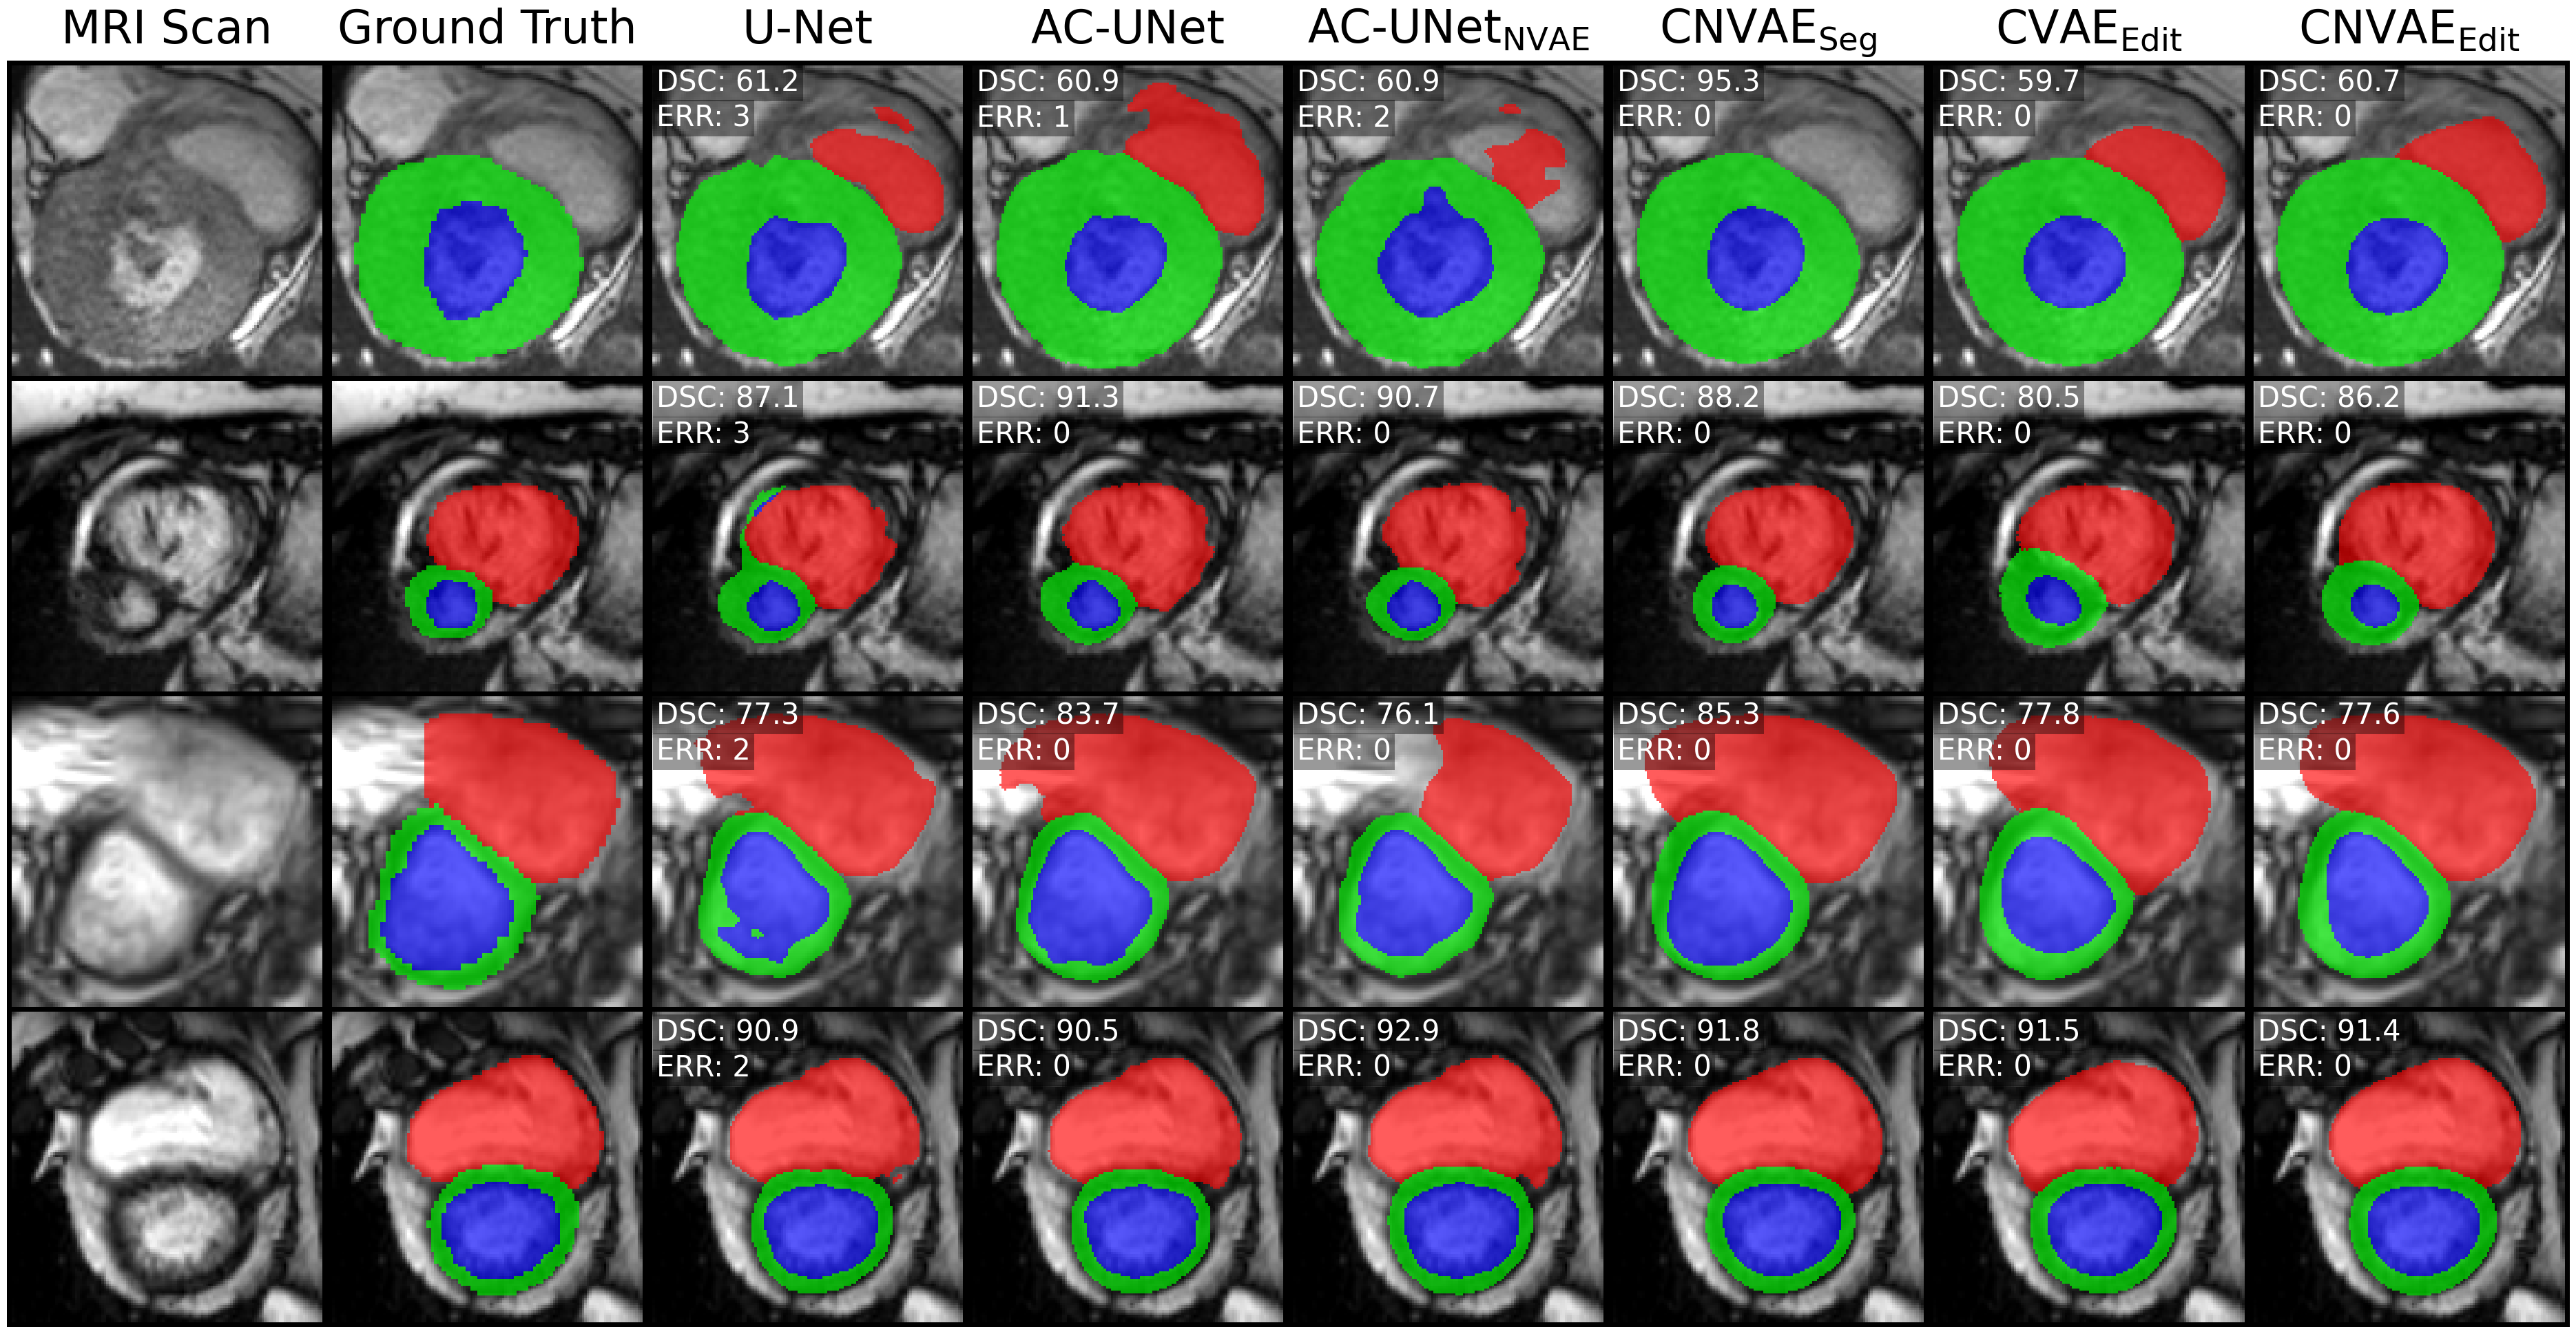

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

from utils.colourmap import GRGB

num_samples = len(samples_idx)

fig, ax = plt.subplots(1, 8, figsize=(48, 6 * num_samples))

# ==============================================================================
# EDIT HERE
# ==============================================================================
    
factor = 1 / num_samples
x_offset = 0.028
y_offset = 0.994
y_offset_2 = 0.966
# word_alpha = 0.64
word_alpha = 0.4
label_size = 30
toplevel_font = 48

# for row in range(num_samples):
#     text = f"INDEX {row}"
    
#     ax[0].text(
#         x_offset, y_offset - row * factor, text, transform=ax[0].transAxes,
#         fontsize=label_size, verticalalignment='top', color='white', 
#         bbox=dict(facecolor='black', alpha=word_alpha, edgecolor='none')
#     )

# Column 1: Scans

scans = worst_x_subset.cpu().float()
scans = make_grid(scans, nrow=1, padding=2)
scans = np.transpose(scans.numpy(), (1, 2, 0))

ax[0].axis("off")
ax[0].imshow(scans)
ax[0].set_title("MRI Scan", fontsize=toplevel_font, pad=18)

# Column 2: Ground truth

ground_truth = ground_truth.cpu().float()
ground_truth_grid = make_grid(ground_truth, nrow=1, padding=2, normalize=True)
ground_truth_grid = ground_truth_grid[0]

ax[1].axis("off")
ax[1].imshow(scans)
alpha_channel = np.ones(ground_truth_grid.shape, dtype=float)
alpha_channel[ground_truth_grid == 0] = 0
alpha_channel[ground_truth_grid != 0] = 0.64
ax[1].imshow(ground_truth_grid, alpha=alpha_channel, cmap=GRGB)
ax[1].set_title("Ground Truth", fontsize=toplevel_font, pad=18)

# Column 3 to 8: U-Net + Corrections

for i, (corrector_id, my_info) in enumerate(segmentation_corrections.items()):
    corrections, dscs, violations = my_info
    
    dscs = dscs.cpu().numpy()
    violations = violations.cpu().numpy()
    
    corrections = corrections.cpu().float()
    corrections_grid = make_grid(corrections, nrow=1, padding=2, normalize=True)
    corrections_grid = corrections_grid[0]

    ax[i + 2].axis("off")
    ax[i + 2].imshow(scans)
    alpha_channel = np.ones(corrections_grid.shape, dtype=float)
    alpha_channel[corrections_grid == 0] = 0
    alpha_channel[corrections_grid != 0] = 0.64
    ax[i + 2].imshow(corrections_grid, alpha=alpha_channel, cmap=GRGB)
    ax[i + 2].set_title(corrector_id, fontsize=toplevel_font, pad=18)
    
    # Show text on top left of each image
    
    for row in range(len(dscs)):
        dsc = dscs[row]
        violation = violations[row]

        dsc_text = f"DSC: {dsc * 100:.1f}"
        violations_text = f"ERR: {violation:.0f}"
        
        ax[i + 2].text(
            x_offset, y_offset - row * factor, dsc_text, transform=ax[i + 2].transAxes,
            fontsize=label_size, verticalalignment='top', color='white', 
            bbox=dict(facecolor='black', alpha=word_alpha, edgecolor='none')
        )
        
        ax[i + 2].text(
            x_offset, y_offset_2 - row * factor, violations_text, transform=ax[i + 2].transAxes,
            fontsize=label_size, verticalalignment='top', color='white', 
            bbox=dict(facecolor='black', alpha=word_alpha, edgecolor='none')
        )

plt.subplots_adjust(wspace=0, hspace=0)